<a href="https://colab.research.google.com/github/Wasiq12345/Membership-adversial-attack/blob/main/MIA_DP_Fast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MIA + DP-SGD Defense — ResNet-18 on CIFAR-10
**CS6413 | Group 12**





## Cell 1 — Install & Imports

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'opacus', '-q'], check=True)

import os, csv, random, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
import torchvision.models as tv_models
import torchvision.models.resnet as resnet_module
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

for d in ['data','outputs/splits','outputs/checkpoints',
          'outputs/checkpoints/shadow_models',
          'outputs/checkpoints/attack_models',
          'outputs/checkpoints/dp_models','outputs/logs']:
    os.makedirs(d, exist_ok=True)

print('All imports OK.')

Device : cuda
GPU    : Tesla T4
All imports OK.


## Cell 2 — Config (tuned for <10 min)

In [2]:
SEED             = 42
TARGET_EPOCHS    = 15    # fast but enough to overfit 6K
NUM_SHADOWS      = 2     # 2 shadows is sufficient for a clear signal
SHADOW_EPOCHS    = 15
SHADOW_IN_SIZE   = 3000
SHADOW_OUT_SIZE  = 3000
ATTACK_EPOCHS    = 20
NUM_CLASSES      = 10
BATCH_SIZE       = 256   # larger batch = faster training
N_AUG_QUERIES    = 2
FEATURE_DIM      = 23
MEMBER_THRESHOLD = np.log(2.0)

DP_EPSILONS      = [10, 5, 1]
DP_DELTA         = 1e-5
DP_MAX_GRAD_NORM = 1.0
DP_EPOCHS        = 15

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed()
print('Config OK.')
print(f'  Target/Shadow epochs : {TARGET_EPOCHS}')
print(f'  Shadow models        : {NUM_SHADOWS}')
print(f'  Batch size           : {BATCH_SIZE}')
print(f'  DP budgets           : ε = {DP_EPSILONS}')

Config OK.
  Target/Shadow epochs : 15
  Shadow models        : 2
  Batch size           : 256
  DP budgets           : ε = [10, 5, 1]


## Cell 3 — Models

In [3]:
class BasicBlockNoInplace(resnet_module.BasicBlock):
    """Removes inplace ops so Opacus DP-SGD works correctly."""
    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out = out + identity    # non-inplace
        out = self.relu(out)
        return out


def build_resnet18(num_classes=10):
    m = tv_models.resnet18(weights=None, num_classes=num_classes)
    m.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    for mod in m.modules():
        if isinstance(mod, resnet_module.BasicBlock):
            mod.__class__ = BasicBlockNoInplace
    for mod in m.modules():
        if isinstance(mod, nn.ReLU):
            mod.inplace = False
    m = ModuleValidator.fix(m)   # BatchNorm → GroupNorm for Opacus
    return m


class AttackMLP(nn.Module):
    def __init__(self, in_dim=FEATURE_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),     nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


errors = ModuleValidator.validate(build_resnet18(), strict=False)
print(f'ResNet-18 params  : {sum(p.numel() for p in build_resnet18().parameters()):,}')
print(f'Opacus validation : {"PASS" if not errors else errors}')

ResNet-18 params  : 11,173,962
Opacus validation : PASS


## Cell 4 — Data & Splits

In [4]:
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds_aug  = datasets.CIFAR10('data', train=True, download=True,  transform=train_tf)
train_ds_eval = datasets.CIFAR10('data', train=True, download=False, transform=eval_tf)

split_path = 'outputs/splits/cifar10_12k_seed42.npz'
if os.path.exists(split_path):
    sp          = np.load(split_path)
    target_idx  = sp['target_idx'].tolist()
    shadow_idx  = sp['shadow_idx'].tolist()
    holdout_idx = sp['holdout_idx'].tolist()
    print('Loaded existing splits.')
else:
    rng         = np.random.RandomState(42)
    all_idx     = rng.permutation(50000)[:12000]
    target_idx  = all_idx[:6000].tolist()
    shadow_idx  = all_idx[6000:9000].tolist()
    holdout_idx = all_idx[9000:12000].tolist()
    np.savez(split_path, target_idx=target_idx,
             shadow_idx=shadow_idx, holdout_idx=holdout_idx)
    print('Created new splits.')

target_train_loader = DataLoader(Subset(train_ds_aug,  target_idx),
                                 batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
target_eval_loader  = DataLoader(Subset(train_ds_eval, target_idx),
                                 batch_size=256, shuffle=False, num_workers=2)
holdout_loader      = DataLoader(Subset(train_ds_eval, holdout_idx),
                                 batch_size=256, shuffle=False, num_workers=2)

print(f'Members: {len(target_idx):,} | Holdout: {len(holdout_idx):,}')

100%|██████████| 170M/170M [00:14<00:00, 12.1MB/s]


Created new splits.
Members: 6,000 | Holdout: 3,000


## Cell 5 — Helper Functions

In [5]:
@torch.no_grad()
def eval_acc(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        correct += (model(x).argmax(1) == y).sum().item()
        total   += y.size(0)
    return correct / total


def train_standard(model, loader, epochs, lr=0.01, wd=0.0, desc=''):
    opt   = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ce    = nn.CrossEntropyLoss()
    model.train()
    for ep in range(1, epochs + 1):
        loss_sum, correct, total = 0.0, 0, 0
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            out  = model(x)
            loss = ce(out, y)
            loss.backward(); opt.step()
            loss_sum += loss.item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            total    += y.size(0)
        sched.step()
        if ep % 5 == 0 or ep == 1:
            print(f'  [{desc}] ep {ep:2d}/{epochs} | '
                  f'loss={loss_sum/total:.3f} | acc={correct/total:.3f}')
    return model


def make_features(conf, labels):
    entropy     = -(conf * (conf + 1e-9).log()).sum(1, keepdim=True)
    max_conf    = conf.max(1, keepdim=True).values
    sorted_conf = conf.sort(1, descending=True).values
    loss        = -conf[torch.arange(len(labels)), labels].log().unsqueeze(1)
    return torch.cat([conf, sorted_conf, entropy, max_conf, loss], dim=1)


@torch.no_grad()
def get_features(model, indices, n_aug=N_AUG_QUERIES):
    idx    = list(indices)
    labels = torch.cat([lbl for _, lbl in
                        DataLoader(Subset(train_ds_eval, idx),
                                   batch_size=256, shuffle=False, num_workers=2)])
    model.eval()
    avg_conf = None
    for _ in range(n_aug):
        conf = torch.cat([
            torch.softmax(model(x.to(DEVICE)), 1).cpu()
            for x, _ in DataLoader(Subset(train_ds_aug, idx),
                                   batch_size=256, shuffle=False, num_workers=2)
        ])
        avg_conf = conf if avg_conf is None else avg_conf + conf
    avg_conf /= n_aug
    return make_features(avg_conf, labels), labels


def run_attack(model, attack_models, label=''):
    model.eval()
    mem_f, mem_l = get_features(model, target_idx)
    non_f, non_l = get_features(model, holdout_idx)
    all_f = torch.cat([mem_f, non_f])
    all_l = torch.cat([mem_l, non_l])
    all_m = torch.cat([
        torch.ones(len(target_idx),   dtype=torch.float32),
        torch.zeros(len(holdout_idx), dtype=torch.float32),
    ])
    preds  = torch.zeros(len(all_m))
    logits = torch.zeros(len(all_m))
    for c in range(NUM_CLASSES):
        atk = attack_models[c]
        if atk is None: continue
        mask = (all_l == c)
        if mask.sum() == 0: continue
        with torch.no_grad():
            lg = atk(all_f[mask].to(DEVICE)).cpu()
        logits[mask] = lg
        preds[mask]  = (lg > MEMBER_THRESHOLD).float()

    y_true  = all_m.numpy()
    y_pred  = preds.numpy()
    y_score = torch.sigmoid(logits).numpy()
    auc     = roc_auc_score(y_true, y_score)
    acc     = accuracy_score(y_true, y_pred)
    rec     = recall_score(y_true, y_pred, zero_division=0)
    cm      = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr     = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    adv     = 2.0 * (rec - fpr)
    m_acc   = eval_acc(model, holdout_loader)
    fpr_arr, tpr_arr, _ = roc_curve(y_true, y_score)

    print(f'  [{label}] ModelAcc={m_acc:.3f} | AtkAcc={acc:.3f} | '
          f'AUC={auc:.3f} | TPR={rec:.3f} | FPR={fpr:.3f} | Adv={adv:.3f}')

    return dict(label=label, model_acc=round(m_acc,4),
                atk_acc=round(acc,4), auc=round(auc,4),
                tpr=round(rec,4), fpr=round(fpr,4), adv=round(adv,4),
                fpr_arr=fpr_arr, tpr_arr=tpr_arr)


print('All helpers defined.')

All helpers defined.


## Cell 6 — Train Baseline + Regularised Targets (~2 min)

In [6]:
# Baseline — no weight decay (overfits → strong MIA signal)
print(f'Training baseline (no DP, no WD) for {TARGET_EPOCHS} epochs...')
t0     = time.time()
target = build_resnet18().to(DEVICE)
target = train_standard(target, target_train_loader, TARGET_EPOCHS,
                         wd=0.0, desc='baseline')
mem_acc  = eval_acc(target, target_eval_loader)
hold_acc = eval_acc(target, holdout_loader)
print(f'  Member acc={mem_acc:.3f} | Holdout acc={hold_acc:.3f} | '
      f'Gap={mem_acc-hold_acc:.3f}')
torch.save(target.state_dict(), 'outputs/checkpoints/best_baseline.pt')
print(f'  Done in {(time.time()-t0)/60:.1f} min')

# Regularised — weight decay 5e-4 (reduces overfitting)
print(f'\nTraining regularised model (WD=5e-4)...')
t0      = time.time()
reg_model = build_resnet18().to(DEVICE)
reg_model = train_standard(reg_model, target_train_loader, TARGET_EPOCHS,
                            wd=5e-4, desc='regularised')
torch.save(reg_model.state_dict(), 'outputs/checkpoints/reg_model.pt')
print(f'  Done in {(time.time()-t0)/60:.1f} min')

print('\nBoth models saved.')

Training baseline (no DP, no WD) for 15 epochs...
  [baseline] ep  1/15 | loss=2.359 | acc=0.121
  [baseline] ep  5/15 | loss=1.818 | acc=0.325
  [baseline] ep 10/15 | loss=1.469 | acc=0.457
  [baseline] ep 15/15 | loss=1.364 | acc=0.501
  Member acc=0.478 | Holdout acc=0.449 | Gap=0.029
  Done in 1.4 min

Training regularised model (WD=5e-4)...
  [regularised] ep  1/15 | loss=2.328 | acc=0.123
  [regularised] ep  5/15 | loss=1.797 | acc=0.338
  [regularised] ep 10/15 | loss=1.456 | acc=0.468
  [regularised] ep 15/15 | loss=1.360 | acc=0.507
  Done in 1.4 min

Both models saved.


## Cell 7 — Train Shadow Models + Attack Classifiers (~4 min)

In [7]:
# Shadow pool
sp   = np.load('outputs/splits/cifar10_12k_seed42.npz')
used = set(sp['target_idx'].tolist() +
           sp['shadow_idx'].tolist()  +
           sp['holdout_idx'].tolist())
pool = np.array([i for i in range(50000) if i not in used])
print(f'Shadow pool: {len(pool):,}')

rng = np.random.default_rng(SEED)
all_feats, all_labels, all_members = [], [], []

t0 = time.time()
for s in range(1, NUM_SHADOWS + 1):
    print(f'\n── Shadow {s}/{NUM_SHADOWS} ──')
    perm    = rng.permutation(len(pool))
    in_idx  = pool[perm[:SHADOW_IN_SIZE]]
    out_idx = pool[perm[SHADOW_IN_SIZE:SHADOW_IN_SIZE + SHADOW_OUT_SIZE]]
    loader  = DataLoader(Subset(train_ds_aug, list(in_idx)),
                         batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    shadow  = build_resnet18().to(DEVICE)
    shadow  = train_standard(shadow, loader, SHADOW_EPOCHS, desc=f'shadow-{s}')
    torch.save(shadow.state_dict(),
               f'outputs/checkpoints/shadow_models/shadow_{s}.pt')
    in_f,  in_l  = get_features(shadow, in_idx)
    out_f, out_l = get_features(shadow, out_idx)
    all_feats.append(torch.cat([in_f,  out_f]))
    all_labels.append(torch.cat([in_l, out_l]))
    all_members.append(torch.cat([
        torch.ones(len(in_idx),   dtype=torch.float32),
        torch.zeros(len(out_idx), dtype=torch.float32),
    ]))

feats   = torch.cat(all_feats)
labels  = torch.cat(all_labels)
members = torch.cat(all_members)
print(f'\nShadow done in {(time.time()-t0)/60:.1f} min | '
      f'Attack training set: {len(members):,}')

# Train attack classifiers
print('\nTraining attack classifiers...')
attack_models = []
for c in range(NUM_CLASSES):
    mask = (labels == c)
    if mask.sum() < 10:
        attack_models.append(None); continue
    X, y    = feats[mask], members[mask]
    loader  = DataLoader(TensorDataset(X, y), batch_size=64, shuffle=True)
    m       = AttackMLP().to(DEVICE)
    opt     = optim.Adam(m.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()
    m.train()
    for _ in range(ATTACK_EPOCHS):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss_fn(m(xb), yb).backward()
            opt.step()
    torch.save(m.state_dict(),
               f'outputs/checkpoints/attack_models/attack_class_{c}.pt')
    attack_models.append(m)

print('All 10 attack classifiers ready.')

Shadow pool: 38,000

── Shadow 1/2 ──
  [shadow-1] ep  1/15 | loss=2.363 | acc=0.117
  [shadow-1] ep  5/15 | loss=2.012 | acc=0.268
  [shadow-1] ep 10/15 | loss=1.732 | acc=0.367
  [shadow-1] ep 15/15 | loss=1.604 | acc=0.423

── Shadow 2/2 ──
  [shadow-2] ep  1/15 | loss=2.354 | acc=0.109
  [shadow-2] ep  5/15 | loss=1.968 | acc=0.270
  [shadow-2] ep 10/15 | loss=1.685 | acc=0.392
  [shadow-2] ep 15/15 | loss=1.571 | acc=0.431

Shadow done in 1.7 min | Attack training set: 12,000

Training attack classifiers...
All 10 attack classifiers ready.


In [10]:
# Force clear all GPU memory before DP training
import gc
try:
    del target, reg_model, shadow, feats, labels, members
except: pass
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f'GPU memory free: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB')

GPU memory free: 0.67 GB


In [11]:
dp_models = {}
DP_BATCH  = 32   # very small batch for Opacus memory constraints

for eps in DP_EPSILONS:
    print(f'\n══ DP ε={eps} ══')
    t0       = time.time()
    gc.collect(); torch.cuda.empty_cache()

    dp_model  = build_resnet18().to(DEVICE)
    dp_loader = DataLoader(
        Subset(train_ds_aug, target_idx),
        batch_size=DP_BATCH, shuffle=True,
        num_workers=0, drop_last=True,
    )
    dp_opt = optim.SGD(dp_model.parameters(), lr=0.01, momentum=0)
    privacy_engine = PrivacyEngine()
    dp_model, dp_opt, dp_loader = privacy_engine.make_private_with_epsilon(
        module=dp_model, optimizer=dp_opt, data_loader=dp_loader,
        epochs=DP_EPOCHS, target_epsilon=eps,
        target_delta=DP_DELTA, max_grad_norm=DP_MAX_GRAD_NORM,
    )
    print(f'  Noise multiplier: {dp_opt.noise_multiplier:.3f}')

    ce = nn.CrossEntropyLoss()
    dp_model.train()
    for ep in range(1, DP_EPOCHS + 1):
        loss_sum, correct, total = 0.0, 0, 0
        for x, y in dp_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            dp_opt.zero_grad()
            out  = dp_model(x)
            loss = ce(out, y)
            loss.backward(); dp_opt.step()
            loss_sum += loss.item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            total    += y.size(0)
        if ep % 5 == 0 or ep == 1:
            spent = privacy_engine.get_epsilon(DP_DELTA)
            print(f'  ep {ep:2d}/{DP_EPOCHS} | '
                  f'loss={loss_sum/total:.3f} | acc={correct/total:.3f} | '
                  f'ε_spent={spent:.2f}')

    ckpt = f'outputs/checkpoints/dp_models/dp_eps{eps}.pt'
    torch.save(dp_model._module.state_dict(), ckpt)
    del dp_model, dp_opt, dp_loader, privacy_engine
    gc.collect(); torch.cuda.empty_cache()
    print(f'  Saved | Time: {(time.time()-t0)/60:.1f} min')
    dp_models[eps] = ckpt

print('\nAll DP models trained.')


══ DP ε=10 ══


  Noise multiplier: 0.529
  ep  1/15 | loss=2.329 | acc=0.099 | ε_spent=4.54
  ep  5/15 | loss=2.289 | acc=0.131 | ε_spent=6.75
  ep 10/15 | loss=2.273 | acc=0.149 | ε_spent=8.54
  ep 15/15 | loss=2.249 | acc=0.187 | ε_spent=9.99
  Saved | Time: 5.2 min

══ DP ε=5 ══


  Noise multiplier: 0.647
  ep  1/15 | loss=2.312 | acc=0.102 | ε_spent=2.35
  ep  5/15 | loss=2.289 | acc=0.140 | ε_spent=3.42
  ep 10/15 | loss=2.267 | acc=0.156 | ε_spent=4.29
  ep 15/15 | loss=2.240 | acc=0.188 | ε_spent=5.00
  Saved | Time: 5.0 min

══ DP ε=1 ══


  Noise multiplier: 1.299
  ep  1/15 | loss=2.317 | acc=0.099 | ε_spent=0.26
  ep  5/15 | loss=2.296 | acc=0.116 | ε_spent=0.57
  ep 10/15 | loss=2.279 | acc=0.145 | ε_spent=0.81
  ep 15/15 | loss=2.270 | acc=0.151 | ε_spent=0.99
  Saved | Time: 5.0 min

All DP models trained.


## Cell 9 — Evaluate All Models

In [14]:
all_results = []

# Baseline — reload from disk
target = build_resnet18().to(DEVICE)
target.load_state_dict(torch.load('outputs/checkpoints/best_baseline.pt',
                                   map_location=DEVICE))
all_results.append(run_attack(target, attack_models, label='No defense'))
del target; torch.cuda.empty_cache()

# Regularised — reload from disk
reg_model = build_resnet18().to(DEVICE)
reg_model.load_state_dict(torch.load('outputs/checkpoints/reg_model.pt',
                                      map_location=DEVICE))
all_results.append(run_attack(reg_model, attack_models, label='Regularised'))
del reg_model; torch.cuda.empty_cache()

# DP models — reload each from disk
for eps in DP_EPSILONS:
    m = build_resnet18().to(DEVICE)
    m.load_state_dict(torch.load(f'outputs/checkpoints/dp_models/dp_eps{eps}.pt',
                                  map_location=DEVICE))
    all_results.append(run_attack(m, attack_models, label=f'DP ε={eps}'))
    del m; torch.cuda.empty_cache()

print('All evaluations done.')

  [No defense] ModelAcc=0.449 | AtkAcc=0.333 | AUC=0.514 | TPR=0.001 | FPR=0.001 | Adv=-0.000
  [Regularised] ModelAcc=0.467 | AtkAcc=0.334 | AUC=0.511 | TPR=0.001 | FPR=0.000 | Adv=0.001
  [DP ε=10] ModelAcc=0.210 | AtkAcc=0.333 | AUC=0.504 | TPR=0.000 | FPR=0.000 | Adv=0.000
  [DP ε=5] ModelAcc=0.205 | AtkAcc=0.333 | AUC=0.500 | TPR=0.000 | FPR=0.000 | Adv=0.000
  [DP ε=1] ModelAcc=0.157 | AtkAcc=0.333 | AUC=0.496 | TPR=0.000 | FPR=0.000 | Adv=0.000
All evaluations done.


## Cell 10 — Comparison Table

In [15]:
print('\n' + '═'*72)
print('  MIA Results: No Defense vs Regularised vs DP-SGD')
print('═'*72)
print(f'  {"Setting":<18} {"ModelAcc":>9} {"AtkAcc":>9} '
      f'{"AUC":>9} {"TPR":>9} {"FPR":>9} {"Adv":>9}')
print('─'*72)
for r in all_results:
    print(f'  {r["label"]:<18} '
          f'{r["model_acc"]:>9.4f} {r["atk_acc"]:>9.4f} '
          f'{r["auc"]:>9.4f} {r["tpr"]:>9.4f} '
          f'{r["fpr"]:>9.4f} {r["adv"]:>9.4f}')
print('═'*72)
print('  ModelAcc = holdout accuracy  |  AUC 0.5=random 1.0=perfect')
print('  Adv      = attacker advantage (0=no info, 1=perfect)')
print('═'*72)


════════════════════════════════════════════════════════════════════════
  MIA Results: No Defense vs Regularised vs DP-SGD
════════════════════════════════════════════════════════════════════════
  Setting             ModelAcc    AtkAcc       AUC       TPR       FPR       Adv
────────────────────────────────────────────────────────────────────────
  No defense            0.4490    0.3334    0.5144    0.0005    0.0007   -0.0003
  Regularised           0.4670    0.3338    0.5107    0.0008    0.0003    0.0010
  DP ε=10               0.2103    0.3333    0.5037    0.0000    0.0000    0.0000
  DP ε=5                0.2053    0.3333    0.5005    0.0000    0.0000    0.0000
  DP ε=1                0.1567    0.3333    0.4955    0.0000    0.0000    0.0000
════════════════════════════════════════════════════════════════════════
  ModelAcc = holdout accuracy  |  AUC 0.5=random 1.0=perfect
  Adv      = attacker advantage (0=no info, 1=perfect)
══════════════════════════════════════════════════════

## Cell 11 — Defense Comparison Plot

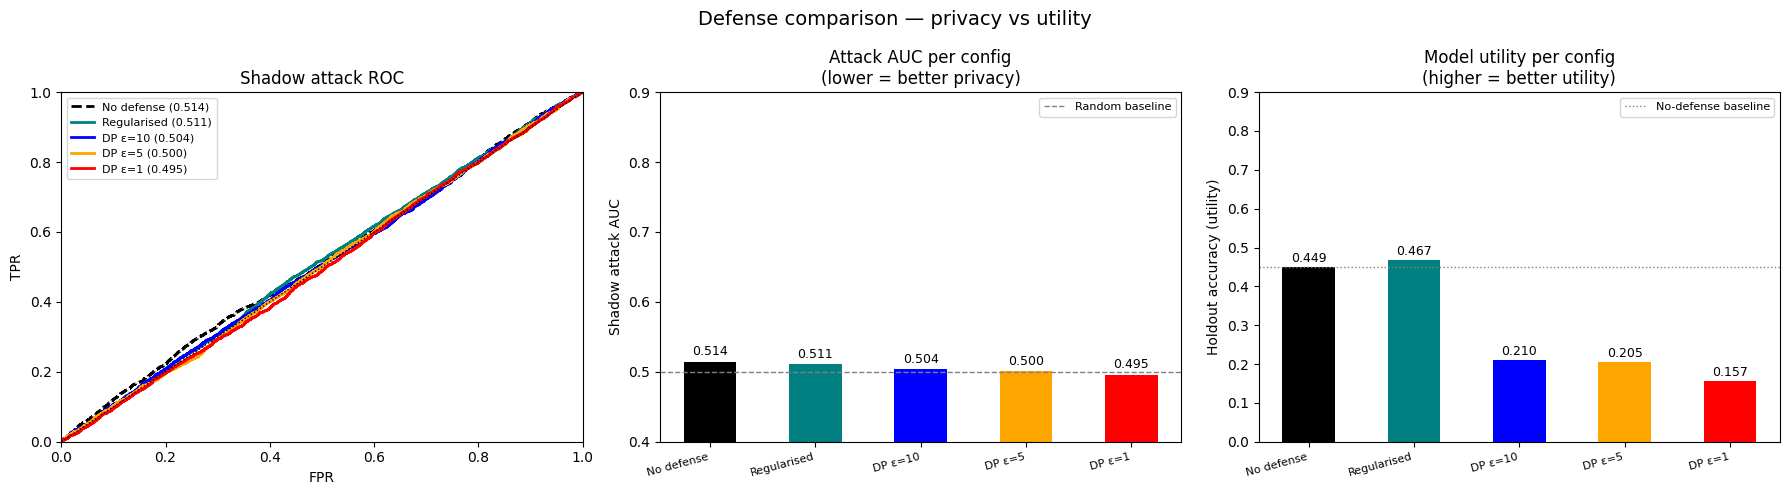

Plot saved.


In [16]:
colors = ['black', 'teal', 'blue', 'orange', 'red']
styles = ['--', '-', '-', '-', '-']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Defense comparison — privacy vs utility', fontsize=14)

# 1 — ROC curves
ax = axes[0]
for r, c, ls in zip(all_results, colors, styles):
    ax.plot(r['fpr_arr'], r['tpr_arr'], color=c, linestyle=ls,
            label=f'{r["label"]} ({r["auc"]:.3f})', lw=2)
ax.plot([0,1],[0,1],'k:',lw=1)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Shadow attack ROC')
ax.legend(fontsize=8); ax.set_xlim(0,1); ax.set_ylim(0,1)

# 2 — AUC bar chart
ax    = axes[1]
lbls  = [r['label'] for r in all_results]
aucs  = [r['auc']   for r in all_results]
bars  = ax.bar(lbls, aucs, color=colors, width=0.5)
ax.axhline(0.5, color='gray', linestyle='--', lw=1, label='Random baseline')
ax.set_ylim(0.4, 0.9)
ax.set_title('Attack AUC per config\n(lower = better privacy)')
ax.set_ylabel('Shadow attack AUC')
ax.legend(fontsize=8)
for bar, val in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=8)

# 3 — Model accuracy bar chart
ax    = axes[2]
maccs = [r['model_acc'] for r in all_results]
bars  = ax.bar(lbls, maccs, color=colors, width=0.5)
ax.axhline(maccs[0], color='gray', linestyle=':', lw=1, label='No-defense baseline')
ax.set_ylim(0, 0.9)
ax.set_title('Model utility per config\n(higher = better utility)')
ax.set_ylabel('Holdout accuracy (utility)')
ax.legend(fontsize=8)
for bar, val in zip(bars, maccs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/logs/defense_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## Cell 12 — Save & Download

In [17]:
# Save CSV (exclude numpy arrays)
csv_results = [{k: v for k, v in r.items()
                if k not in ('fpr_arr','tpr_arr')}
               for r in all_results]

csv_path = 'outputs/logs/mia_vs_dp_comparison.csv'
with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(csv_results[0].keys()))
    w.writeheader(); w.writerows(csv_results)
print(f'CSV saved: {csv_path}')

from google.colab import files
files.download(csv_path)
files.download('outputs/logs/defense_comparison.png')
print('Downloads started.')

CSV saved: outputs/logs/mia_vs_dp_comparison.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started.
